<img src="https://devra.ai/analyst/notebook/5933/image.jpg" style="width: 100%; height: auto;" />

<div style="text-align:center; border-radius:15px; padding:15px; color:white; margin:0; font-family: 'Orbitron', sans-serif; background: #2E0249; background: #11001C; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.3); overflow:hidden; margin-bottom: 1em;"><div style="font-size:150%; color:#FEE100"><b>Spotify Streaming Data Analysis Notebook</b></div><div>This notebook was created with the help of <a href="https://devra.ai/ref/kaggle" style="color:#6666FF">Devra AI</a></div></div>

# Spotify Streaming Data Analysis

Streaming data tells an intriguing story about daily rhythms and musical tastes. In this notebook we dive into multiple Spotify streaming datasets, exploring daily listening habits and album-level details from April 2025 to April 2026. If you find the insights useful, please consider an upvote. We might even predict stream counts with a dash of dry humor along the way.

## Table of Contents

- [Imports and Setup](#Imports-and-Setup)
- [Data Loading](#Data-Loading)
- [Data Cleaning and Preprocessing](#Data-Cleaning-and-Preprocessing)
- [Exploratory Data Analysis](#Exploratory-Data-Analysis)
- [Predictive Modeling](#Predictive-Modeling)
- [Summary and Future Work](#Summary-and-Future-Work)

In [1]:
# Imports and Setup
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')  # Using Agg backend for remote plotting
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # Ensure backend is set appropriately if only plt is imported
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Helper function to resolve data file paths
from pathlib import Path

DATA_ROOTS = [
    Path('/kaggle/input'),
    Path('/kaggle/input'),
    Path('/kaggle/input/datasets'),
]

def resolve_data_file(file_name=None, suffixes=None):
    suffixes = tuple(suffixes or [])
    for root in DATA_ROOTS:
        if not root.exists():
            continue
        matches = [p for p in root.rglob('*') if p.is_file()]
        if file_name:
            exact = [p for p in matches if p.name == file_name]
            if exact:
                return exact[0]
        if suffixes:
            typed = [p for p in matches if p.suffix.lower() in suffixes]
            if typed:
                return typed[0]
    raise FileNotFoundError(f'Could not resolve data file: {file_name or suffixes}')

## Data Loading

Here we load three datasets related to Spotify streaming data:

1. Daily streaming data
2. Album counts data
3. Specific streaming data for 4.25 to 4.26

In [2]:
# Load Spotify daily streaming data
daily_file = resolve_data_file(file_name='spotify_skz_counts_day.csv', suffixes=['.csv'])
df_daily = pd.read_csv(daily_file, delimiter=',', encoding='ascii')

print('Daily Streaming Data Shape:', df_daily.shape)
display(df_daily.head())

Daily Streaming Data Shape: (1808, 11)


,end_year,end_month,end_date,end_day,end_hour_UTC,end_hour_PST,number_of_streams,total_time_played_ms,total_time_played_h,average_ms_played,average_min_played
0,2025,4,17,Thursday,19,11,1,140543,0:02:21,140543.00,0:02:21
1,2025,4,18,Friday,15,7,14,2317668,0:38:38,165547.71,0:02:46
2,2025,4,18,Friday,16,8,19,3582198,0:59:42,188536.74,0:03:09
3,2025,4,18,Friday,17,9,19,3709003,1:01:49,195210.68,0:03:15
4,2025,4,18,Friday,18,10,19,3530449,0:58:50,185813.11,0:03:06


In [3]:
# Load Spotify album streaming data
album_file = resolve_data_file(file_name='spotify_skz_counts_album.csv', suffixes=['.csv'])
df_album = pd.read_csv(album_file, delimiter=',', encoding='ascii')

print('Album Streaming Data Shape:', df_album.shape)
display(df_album.head())

Album Streaming Data Shape: (309, 12)


,release_year,album_type,album_name,track_name,bpm,number_of_streams,total_time_played,total_time_played_h,average_ms_played,average_ms_played_min,song_length_min,avg_percent_song_played
0,2018,Mini Album,I am NOT,3rd Eye,140,32,7554514,2:05:55,236078.56,3:56,4:03,97
1,2018,Mini Album,I am NOT,Awaken,164,33,6399256,1:46:39,193916.85,3:13,3:13,100
2,2018,Mini Album,I am NOT,District 9,90,151,32233152,8:57:13,213464.58,3:33,3:33,100
3,2018,Mini Album,I am NOT,Grow Up,174,23,4881245,1:21:21,212228.04,3:32,3:33,100
4,2018,Mini Album,I am NOT,Mirror,186,26,5329113,1:28:49,204965.88,3:25,3:42,92


In [4]:
# Load Spotify streaming data for 4.25 to 4.26
stream_file = resolve_data_file(file_name='spotify_skz_streaming_4.25_4.26.csv', suffixes=['.csv'])
df_stream = pd.read_csv(stream_file, delimiter=',', encoding='MacRoman')

print('4.25 to 4.26 Streaming Data Shape:', df_stream.shape)
display(df_stream.head())

4.25 to 4.26 Streaming Data Shape: (27005, 16)


,end_time,end_year,end_month,end_date,end_day,end_hour_UTC,end_hour_PST,artist_name,track_name,album_name,release_year,release_country,album_type,played_ms,played_min,played_h
0,4/17/2025 19:42,2025,4,17,Thursday,19,11,Stray Kids,Truman (HAN and Felix),Mixtape - DominATE,2025,South Korea,Mixtape,140543,2:21,0:02
1,4/18/2025 15:18,2025,4,18,Friday,15,7,Stray Kids,Truman (HAN and Felix),Mixtape - DominATE,2025,South Korea,Mixtape,23984,0:24,0:00
2,4/18/2025 15:21,2025,4,18,Friday,15,7,Stray Kids,Burnin' Tires (Changbin and I.N),Mixtape - DominATE,2025,South Korea,Mixtape,172413,2:52,0:02
3,4/18/2025 15:24,2025,4,18,Friday,15,7,Stray Kids,Truman (HAN and Felix),Mixtape - DominATE,2025,South Korea,Mixtape,194400,3:14,0:03
4,4/18/2025 15:28,2025,4,18,Friday,15,7,Stray Kids,ESCAPE (Bang Chan and Hyunjin),Mixtape - DominATE,2025,South Korea,Mixtape,190166,3:10,0:03


## Data Cleaning and Preprocessing

We now clean the data and address the error encountered when constructing date columns. A previous attempt at combining year, month, and day columns produced the error:

  ValueError: to assemble mappings requires at least that [year, month, day] be specified: [month,year] is missing

This error occurred because the columns were not renamed consistently. To correct this, we rename the columns to the expected names: 'year', 'month', and 'day'.

In [5]:
# Before constructing the date column, we rename the appropriate columns
if all(col in df_daily.columns for col in ['end_year', 'end_month', 'end_date']):
    # Renaming columns to 'year', 'month', and 'day' so that pd.to_datetime can correctly interpret them
    df_daily_date = df_daily.rename(columns={'end_year': 'year', 'end_month': 'month', 'end_date': 'day'})
    df_daily_date['date'] = pd.to_datetime(df_daily_date[['year', 'month', 'day']])
    print('Successfully constructed datetime column from components:')
    display(df_daily_date[['year', 'month', 'day', 'date']].head())
else:
    print('Required date columns not found in df_daily')

# In a production setting, note the importance of consistent naming. Many notebook creators run into this renaming issue when assembling dates from components.

Successfully constructed datetime column from components:


,year,month,day,date
0,2025,4,17,2025-04-17
1,2025,4,18,2025-04-18
2,2025,4,18,2025-04-18
3,2025,4,18,2025-04-18
4,2025,4,18,2025-04-18


## Exploratory Data Analysis

At this point, we perform some exploratory data analysis. We explore distributions, correlations, and relationships between variables. Several visualization techniques are used to gain insights into streaming habits.

Note: When considering correlation heatmaps, we first reduce the data frame to only numeric columns.

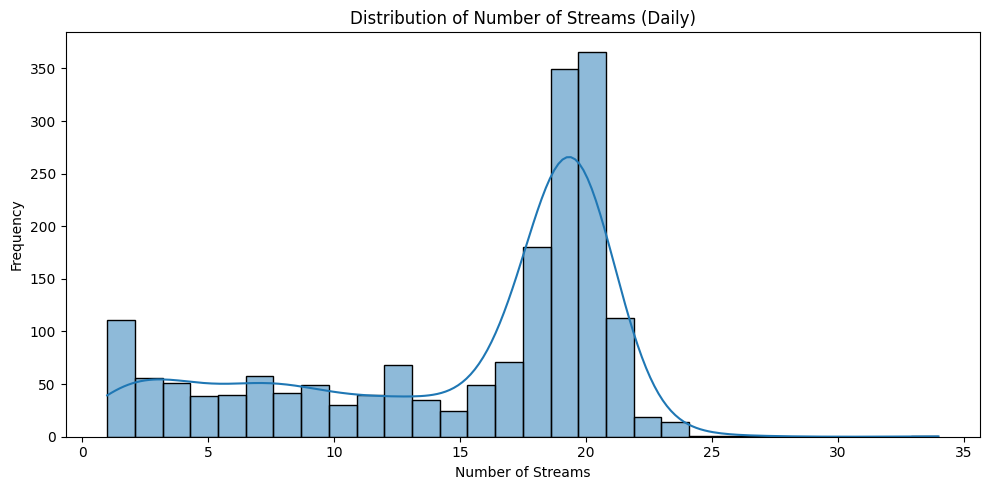

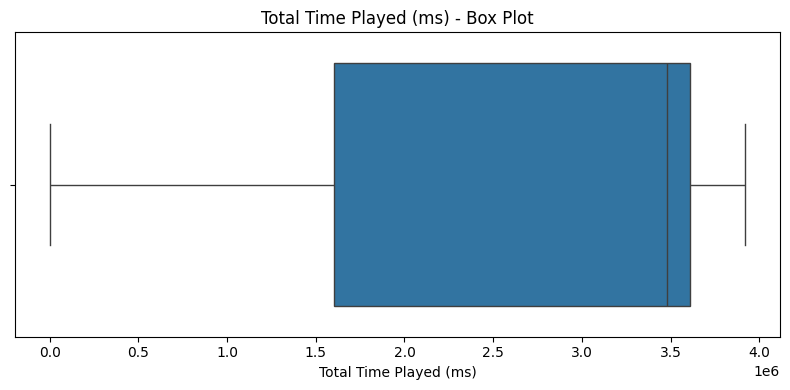

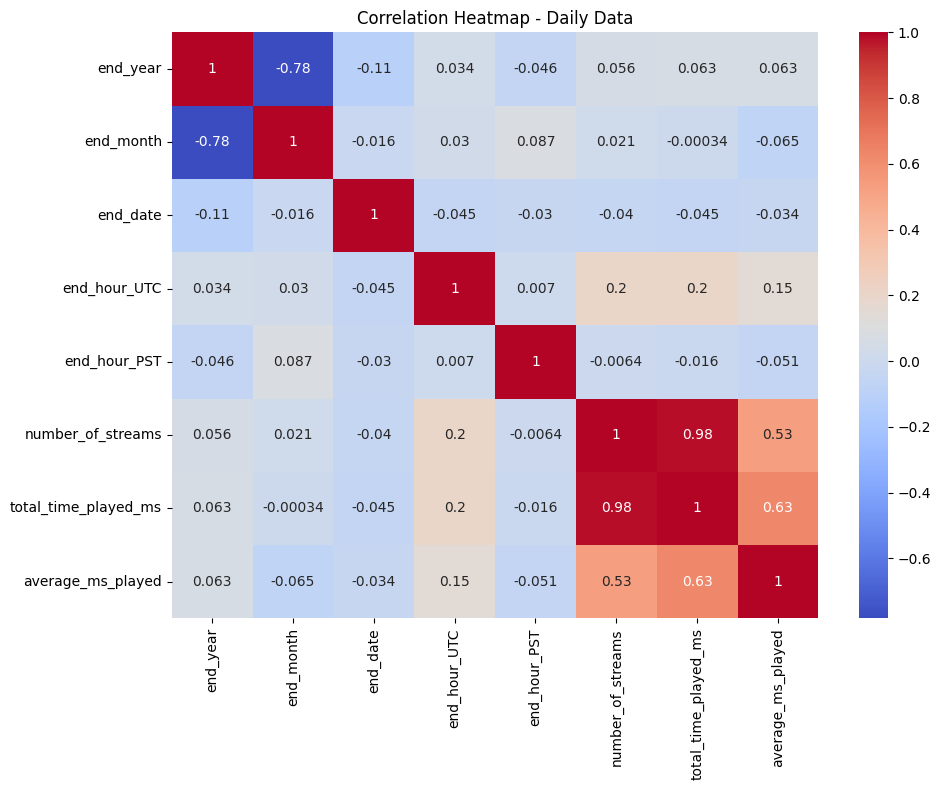

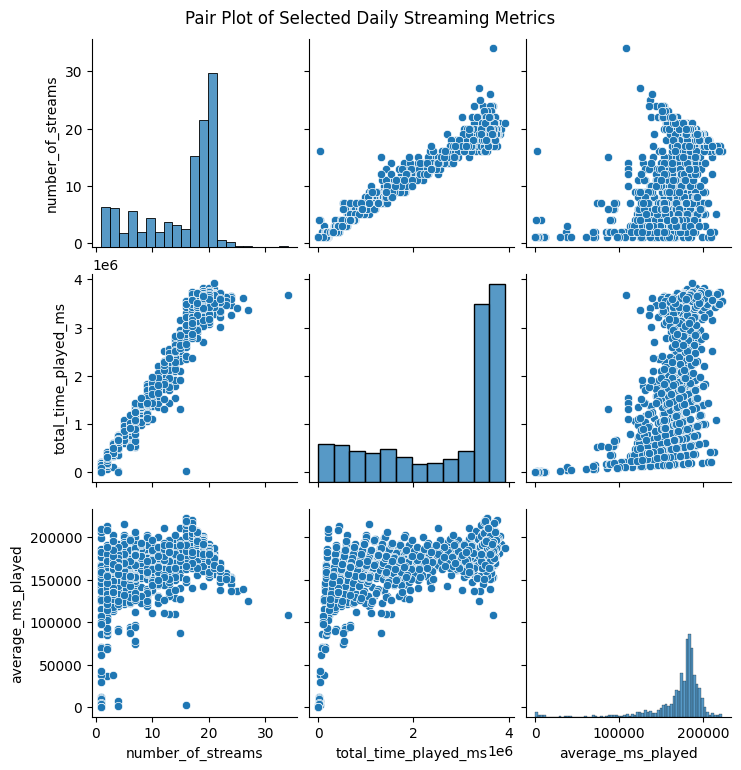

In [6]:
# Exploratory analysis on daily streaming data

# Histogram of number_of_streams
plt.figure(figsize=(10, 5))
sns.histplot(data=df_daily, x='number_of_streams', kde=True, bins=30)
plt.title('Distribution of Number of Streams (Daily)')
plt.xlabel('Number of Streams')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Box Plot to examine outliers in total_time_played_ms
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_daily['total_time_played_ms'])
plt.title('Total Time Played (ms) - Box Plot')
plt.xlabel('Total Time Played (ms)')
plt.tight_layout()
plt.show()

# Correlation heatmap if numeric data contains at least four columns
numeric_df = df_daily.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(10, 8))
    correlation = numeric_df.corr()
    sns.heatmap(correlation, annot=True, cmap='coolwarm')
    plt.title('Correlation Heatmap - Daily Data')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough numeric columns for a correlation heatmap.')

# Pair Plot of a subset of relevant numeric columns for a more detailed relationship view
selected_cols = ['number_of_streams', 'total_time_played_ms', 'average_ms_played']
if all(col in df_daily.columns for col in selected_cols):
    sns.pairplot(df_daily[selected_cols])
    plt.suptitle('Pair Plot of Selected Daily Streaming Metrics', y=1.02)
    plt.show()
else:
    print('Some columns for pair plot are missing.')

## Predictive Modeling

Next, we attempt to build a simple predictor. Let us predict the `number_of_streams` in the daily streaming data using other features. For simplicity we will use a linear regression model. The analysis includes computing the prediction accuracy (R² score). Although this predictor is quite elementary, it lays the groundwork for more sophisticated models in the future.

Linear Regression R² Score: 0.96597779302207


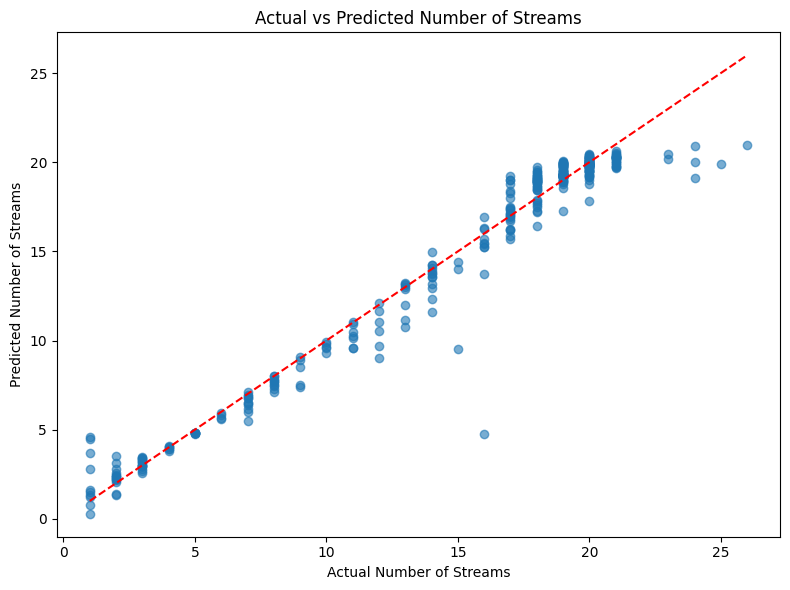

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Choose predictors; we exclude columns like date or identifiers
predictor_cols = [col for col in ['total_time_played_ms', 'average_ms_played'] if col in df_daily.columns]

# Check if we have our target and predictors
if 'number_of_streams' in df_daily.columns and predictor_cols:
    X = df_daily[predictor_cols].dropna()
    y = df_daily.loc[X.index, 'number_of_streams']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred)

    print('Linear Regression R² Score:', score)

    # Plot Actual vs Predicted
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.xlabel('Actual Number of Streams')
    plt.ylabel('Predicted Number of Streams')
    plt.title('Actual vs Predicted Number of Streams')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.tight_layout()
    plt.show()
else:
    print('Target or predictor columns are missing from df_daily.')

## Summary and Future Work

In this notebook we:

- Loaded and examined multiple Spotify streaming datasets
- Addressed a common date assembly error by renaming columns consistently
- Explored the data using various visualization techniques including histograms, box plots, heatmaps, and pair plots
- Built a simple linear regression model to predict daily stream counts

Future work could include more advanced predictive modeling, time-series analysis, and clustering to unearth even richer insights behind listening behavior.

If you found this notebook insightful, please consider an upvote. Happy streaming and coding.